In [1]:
import networkx as nx
from joblib import Parallel, delayed
import random
import itertools
import numpy as np
from gensim.models import Word2Vec
import os

In [2]:
big_data = os.path.join(os.getcwd(), 'Ex17', 'lab1', 'lab1_big_edgelist.txt')
small_data = os.path.join(os.getcwd(), 'Ex17', 'lab1', 'lab1_small_edgelist.txt')

In [3]:
G = nx.read_edgelist(big_data,create_using=nx.DiGraph(),nodetype=None,data=[('weight',int)])# Read graph

In [9]:
G.nodes()

NodeView(('1397', '1470', '362', '226', '750', '489', '1462', '1713', '393', '445', '696', '1610', '889', '1615', '708', '713', '718', '1630', '734', '776', '814', '818', '1401', '220', '1412', '1413', '228', '233', '235', '1450', '236', '1455', '1465', '1466', '1468', '243', '245', '1535', '780', '1550', '2273', '1616', '2158', '1624', '2165', '2167', '1631', '1640', '1659', '1662', '2280', '2307', '16', '11', '48', '68', '67', '88', '116', '119', '493', '167', '181', '15', '64', '66', '73', '92', '172', '186', '63', '436', '100', '101', '107', '458', '1443', '1445', '133', '1567', '890', '1592', '1597', '1601', '1398', '1005', '695', '700', '714', '722', '663', '788', '1018', '509', '811', '1481', '1891', '390', '277', '434', '960', '475', '346', '1716', '1717', '1718', '400', '410', '2159', '1745', '1765', '1799', '1805', '1815', '1829', '1840', '1855', '1865', '1783', '902', '1247', '933', '682', '23', '391', '25', '89', '980', '1394', '1545', '887', '893', '289', '931', '950', '97

In [10]:
G.edges()

OutEdgeView([('1397', '1470'), ('1397', '362'), ('1397', '226'), ('1397', '750'), ('1397', '489'), ('1397', '1462'), ('1397', '1397'), ('1470', '1397'), ('1470', '1525'), ('1470', '359'), ('1470', '1540'), ('1470', '750'), ('1470', '344'), ('1470', '244'), ('362', '372'), ('226', '216'), ('226', '1401'), ('226', '1413'), ('226', '224'), ('226', '225'), ('226', '226'), ('226', '228'), ('226', '229'), ('226', '1445'), ('226', '232'), ('226', '233'), ('226', '235'), ('226', '236'), ('226', '1464'), ('226', '1466'), ('226', '1467'), ('226', '241'), ('226', '242'), ('226', '243'), ('226', '244'), ('226', '526'), ('226', '375'), ('226', '245'), ('226', '246'), ('226', '247'), ('750', '1397'), ('750', '854'), ('750', '1470'), ('750', '1525'), ('750', '1540'), ('750', '747'), ('750', '772'), ('750', '489'), ('750', '1484'), ('750', '2316'), ('750', '750'), ('489', '489'), ('489', '1717'), ('489', '396'), ('489', '405'), ('489', '708'), ('489', '419'), ('489', '425'), ('489', '277'), ('489', '4

In [8]:
len(list(G.nodes()))

2405

In [11]:
len(list(G.edges()))

16523

In [ ]:
with open(big_data, 'r') as f:
    all_edges = f.read()
all_edges = all_edges.split('\n')
len(set(all_edges))  # do có thể có nhiều cạnh trùng lặp nên dùng set để đếm, có thêm dấu xuống dòng ở dòng cuối file nên hơn 1 so với edges

16524

In [5]:
def partition_num(num, workers):
    if num % workers == 0:
        return [num//workers]*workers
    else:
        return [num//workers]*workers + [num % workers]

Trong lab này ta sẽ triển khai deepwalk dựa trên skip gram, ý tưởng là dựa trên embedding node hiện tại dự đoán các embedding của các node lân cận nằm trong cửa sổ w của nó
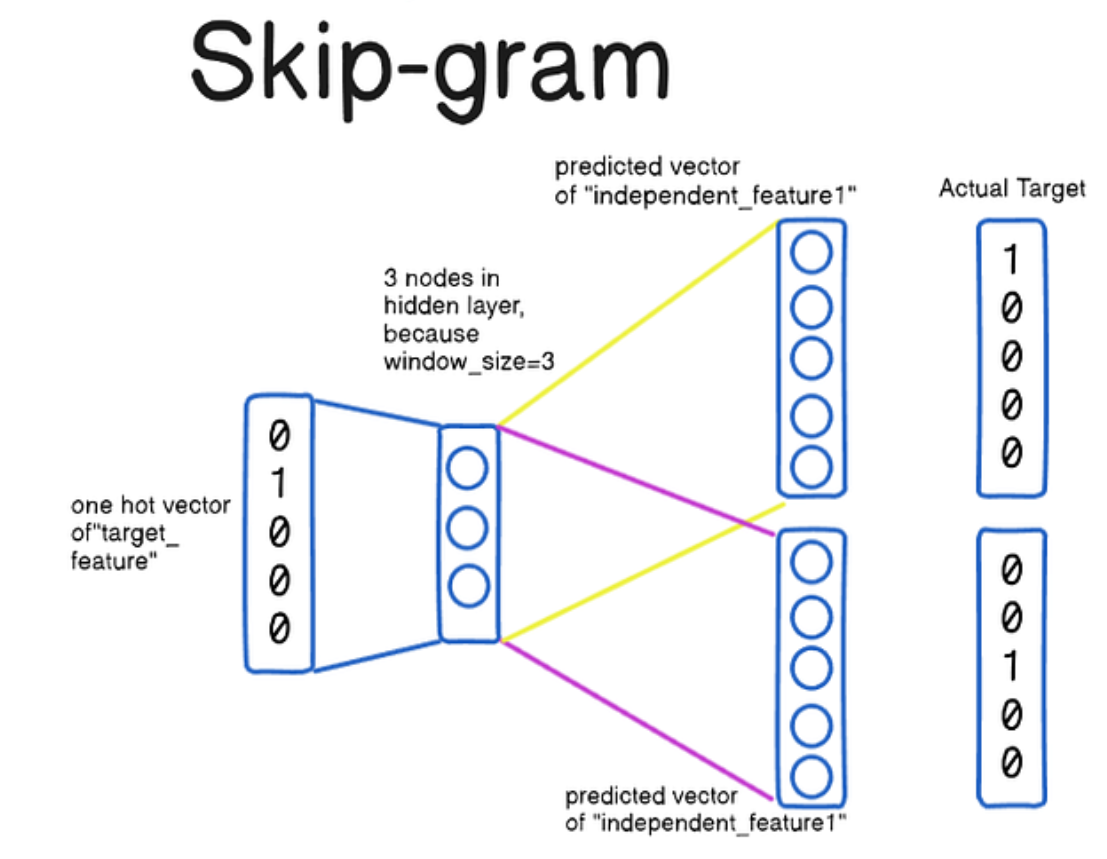

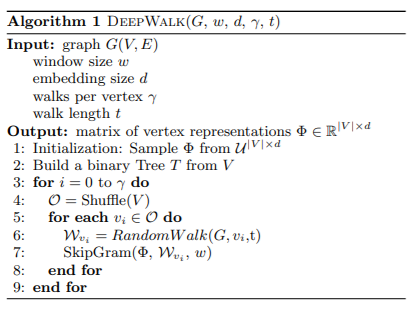

In [71]:
import random
class RandomWalker:
    def __init__(self, G, num_walkers, walk_length):  # num_walkers là số lượng walk được bắt đầu từ 1 đỉnh
        self.G = G
        self.num_walkers = num_walkers
        self.walk_length = walk_length
    
    def simulate_walks(self):
        walks = []
        nodes = list(self.G.nodes())
        for i in range(self.num_walkers):
            random.shuffle(nodes)
            for node in nodes:
                current = node
                check = 1
                walk = []
                for _ in range(self.walk_length):
                    if len(list(self.G.neighbors(current))) == 0:
                        check = 0
                        break
                    walk.append(list(self.G.neighbors(current))[random.randint(0,len(list(self.G.neighbors(current)))-1)])
                    current = list(self.G.neighbors(current))[random.randint(0,len(list(self.G.neighbors(current)))-1)]
                if check:
                    walks.append(walk)
        return walks

Trong đoạn code trên đã bỏ đi các walk không thể đạt được độ dài yêu cầu, điều đó có nghĩa là có thể tồn tại các node mà không nằm trong walk nào vì mọi đường đi từ nó hoặc đến nó đều không đạt yêu cầu về độ dài

In [64]:
small_g = nx.read_edgelist(small_data,create_using=nx.DiGraph(),nodetype=None,data=[('weight',int)])

In [65]:
len(list(small_g.nodes())), len(list(small_g.edges()))

(10, 32)

In [73]:
test_ranwalk = RandomWalker(small_g, 3, 7)
test_ranwalk.simulate_walks()

[['5', '6', '6', '2', '4', '1', '1'],
 ['4', '1', '1', '10', '9', '4', '8'],
 ['6', '9', '2', '10', '1', '1', '4'],
 ['9', '8', '7', '2', '1', '8', '1'],
 ['7', '1', '4', '6', '2', '7', '5'],
 ['10', '3', '9', '10', '8', '6', '9'],
 ['6', '1', '9', '6', '1', '4', '1'],
 ['10', '5', '1', '6', '7', '10', '1'],
 ['1', '5', '2', '10', '10', '1', '1'],
 ['10', '10', '4', '9', '2', '7', '8'],
 ['6', '3', '6', '6', '1', '4', '1'],
 ['7', '4', '1', '10', '1', '10', '1'],
 ['6', '1', '2', '7', '10', '9', '10'],
 ['1', '8', '8', '9', '10', '1', '10'],
 ['6', '1', '10', '10', '1', '1', '8'],
 ['4', '1', '9', '2', '5', '3', '2'],
 ['10', '1', '8', '6', '2', '10', '1'],
 ['2', '2', '6', '9', '1', '1', '8'],
 ['2', '2', '5', '6', '10', '10', '10'],
 ['4', '8', '6', '2', '10', '8', '9'],
 ['8', '8', '6', '1', '10', '2', '7'],
 ['9', '10', '1', '10', '4', '9', '8'],
 ['3', '6', '6', '2', '10', '1', '10'],
 ['1', '5', '2', '1', '5', '8', '2'],
 ['6', '10', '6', '10', '5', '2', '5'],
 ['1', '9', '2', '7

In [101]:
class DeepWalk:
    def __init__(self, graph, walk_length, num_walks):

        self.graph = graph
        self.w2v_model = None
        self._embeddings = {}

        self.walker = RandomWalker(graph, num_walkers=num_walks, walk_length=walk_length)
        self.walks = self.walker.simulate_walks()

    def train(self, embed_size=128, window_size=5, workers=1, iter=5, **kwargs):

        kwargs["sentences"] = self.walks
        kwargs["min_count"] = kwargs.get("min_count", 0)
        kwargs["vector_size"] = embed_size
        kwargs["sg"] = 1  # skip gram
        kwargs["hs"] = 1  # deepwalk use Hierarchical Softmax
        kwargs["workers"] = workers
        kwargs["window"] = window_size
        kwargs["epochs"] = iter

        print("Learning embedding vectors...")
        model = Word2Vec(**kwargs) # Pay attention here
        print("Learning embedding vectors done!")

        self.w2v_model = model
        return model

    def get_embeddings(self,):
        if self.w2v_model is None:
            print("model not train")
            return {}
        self._embeddings = {}
        remain_nodes = self.w2v_model.wv.index_to_key
        for word in self.graph.nodes():
            if word in remain_nodes:
                self._embeddings[word] = self.w2v_model.wv[word]
        return self._embeddings


In [102]:
model = DeepWalk(G, 10, 80)
model.train(window_size = 5, iter = 5)
embeddings = model.get_embeddings()

Learning embedding vectors...
Learning embedding vectors done!


In [105]:
len(embeddings.keys())

2045

từ 2405 nodes còn 2045 node có embedding

In [110]:
embeddings

{'1397': array([ 0.06388464, -0.09185814,  0.0040199 , -0.06972289, -0.104543  ,
        -0.02094232, -0.23962823, -0.29473272,  0.22331704,  0.13460988,
         0.3381704 , -0.32078117,  0.10684949, -0.31898096, -0.10840444,
        -0.11433681,  0.4121267 , -0.12303636, -0.18755874,  0.2617056 ,
        -0.15773475, -0.3469048 , -0.24650288, -0.40232968,  0.3983841 ,
        -0.11482568, -0.2208615 , -0.4593666 ,  0.15434732, -0.10401597,
         0.21598475, -0.06308506,  0.17323896,  0.32967788, -0.20099507,
         0.15743612,  0.33510014,  0.07734291,  0.21842149,  0.00530706,
         0.28083628,  0.12099006, -0.0424127 ,  0.13633296, -0.49794605,
        -0.08675943,  0.17397453,  0.4224642 ,  0.06258661, -0.04898129,
         0.49089205, -0.15573339,  0.01886607, -0.27143115,  0.19470845,
         0.24963309,  0.24918255, -0.00529218,  0.42713186,  0.19260025,
        -0.3602091 ,  0.4084047 , -0.2128273 , -0.14081639,  0.02787797,
         0.36348614, -0.00992125, -0.006384